<a href="https://colab.research.google.com/github/cszydlow-lgtm/SAT5114Project/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
# =========================
# IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, auc
)

In [32]:
# =========================
# LOAD DATA (BUILT-IN)
# =========================
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target

In [43]:
# =========================
# DATASET VIEW + UNITS
# =========================
df = pd.DataFrame(X, columns=cancer.feature_names)

print("\n=== DATASET PREVIEW ===")
print(df.head())

print("\n=== DATASET SHAPE ===")
print(df.shape)

print("\n=== CLASS DISTRIBUTION ===")
print(pd.Series(y).value_counts())

print("\n=== FEATURE NAMES ===")
print(cancer.feature_names)

print("\n=== TARGET CLASSES ===")
print(cancer.target_names)

print("\n=== FEATURE DESCRIPTIONS (WITH UNITS) ===")

feature_units = {
    "mean radius": "mm (tumor radius)",
    "mean texture": "std of gray-scale values",
    "mean perimeter": "mm",
    "mean area": "mm^2",
    "mean smoothness": "unitless",
    "mean compactness": "unitless",
    "mean concavity": "unitless",
    "mean concave points": "unitless",
    "mean symmetry": "unitless",
    "mean fractal dimension": "unitless",
}

for feature, unit in feature_units.items():
    print(f"{feature}: {unit}")

print("\n=== SUMMARY STATISTICS ===")
print(df.describe())


=== DATASET PREVIEW ===
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst 

In [34]:
# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
# =========================
# FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
# =======================
# LOGISTIC REGRESSION
# =======================
X_train_lr = X_train.T
X_test_lr = X_test.T
y_train_lr = y_train.reshape(1, -1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic(X, y, lr=0.01, iterations=1500):
    w = np.zeros((X.shape[0], 1))
    b = 0.0
    m = X.shape[1]

    for _ in range(iterations):
        z = np.dot(w.T, X) + b
        y_hat = sigmoid(z)

        dw = (1/m) * np.dot(X, (y_hat - y).T)
        db = (1/m) * np.sum(y_hat - y)

        w -= lr * dw
        b -= lr * db

    return w, b

def predict_lr(w, b, X):
    return (sigmoid(np.dot(w.T, X) + b) > 0.5).astype(int).flatten()

def predict_proba_lr(w, b, X):
    return sigmoid(np.dot(w.T, X) + b).flatten()

# Train model
w, b = train_logistic(X_train_lr, y_train_lr)

y_pred_lr = predict_lr(w, b, X_test_lr)
y_prob_lr = predict_proba_lr(w, b, X_test_lr)


=== LOGISTIC REGRESSION ===
Accuracy: 0.9912280701754386
Precision: 0.9861111111111112
Recall: 1.0
F1 Score: 0.993006993006993

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



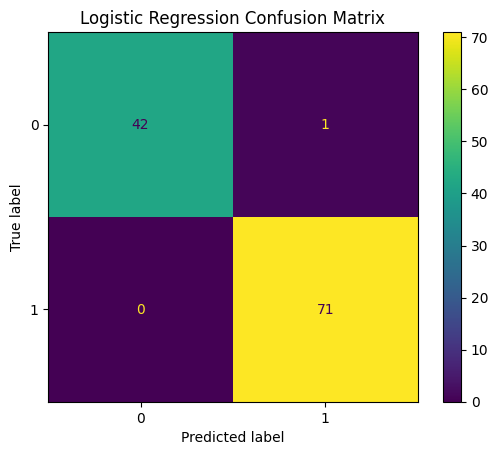


Logistic Regression False Negatives: 0
→ 0 malignant tumors were misclassified as benign.


In [41]:
# =========================
# LOGISTIC METRICS
# =========================
print("\n=== LOGISTIC REGRESSION ===")
print("Accuracy:", np.mean(y_pred_lr == y_test))
print("Precision:", precision_score(y_test, y_pred_lr, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_lr, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_lr, zero_division=0))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"\nLogistic Regression False Negatives: {fn}")
print(f"→ {fn} malignant tumors were misclassified as benign.")

In [46]:
# =========================================================
# KNN WITH FAST HYPERPARAMETER TUNING
# =========================================================
print("\n=== KNN TUNING ===")

param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

print("Best Cross-Validation F1 Score:", round(grid.best_score_, 4))

print("\nAll Results:")
for params, score in zip(grid.cv_results_['params'],
                         grid.cv_results_['mean_test_score']):
    print(f"  K={params['n_neighbors']}, weights={params['weights']:10s} → F1 = {score:.4f}")

best_knn = grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]


=== KNN TUNING ===
Best Parameters: {'n_neighbors': 7, 'weights': 'uniform'}
Best Cross-Validation F1 Score: 0.9711

All Results:
  K=3, weights=uniform    → F1 = 0.9655
  K=3, weights=distance   → F1 = 0.9655
  K=5, weights=uniform    → F1 = 0.9710
  K=5, weights=distance   → F1 = 0.9710
  K=7, weights=uniform    → F1 = 0.9711
  K=7, weights=distance   → F1 = 0.9711



=== TUNED KNN ===
Accuracy: 0.9473684210526315
Precision: 0.9577464788732394
Recall: 0.9577464788732394
F1 Score: 0.9577464788732394

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



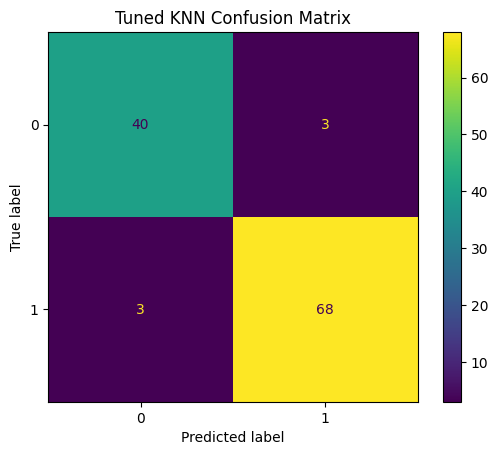


KNN False Negatives: 3
→ 3 malignant tumors were misclassified as benign.
→ In a clinical setting, these represent missed cancer diagnoses.


In [42]:
# =========================
# KNN METRICS
# =========================
print("\n=== TUNED KNN ===")
print("Accuracy:", best_knn.score(X_test, y_test))
print("Precision:", precision_score(y_test, y_pred_knn, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_knn, zero_division=0))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot()
plt.title("Tuned KNN Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm_knn.ravel()
print(f"\nKNN False Negatives: {fn}")
print(f"→ {fn} malignant tumors were misclassified as benign.")
print(f"→ In a clinical setting, these represent missed cancer diagnoses.")

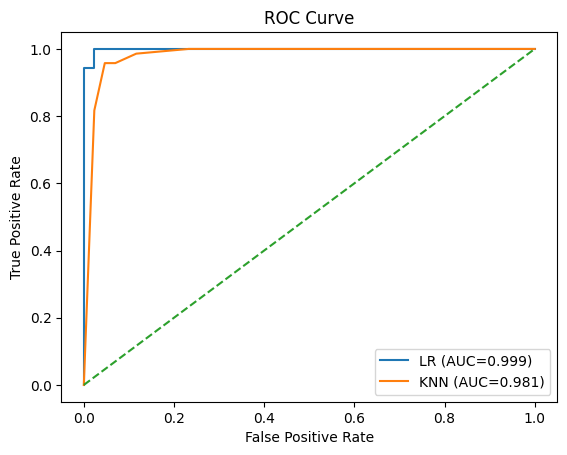


=== AUC SCORES ===
Logistic Regression: 0.998689813298395
KNN: 0.980510972813626


In [40]:
# =========================================================
# ROC CURVE + AUC
# =========================================================
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={auc_lr:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("\n=== AUC SCORES ===")
print("Logistic Regression:", auc_lr)
print("KNN:", auc_knn)